# The Fermi-Pasta-Ulam-Tsingou problem

Jacopo Tissino  
June 9, 2026

In [1]:
import matplotlib.pyplot as plt
from project_scripts.simulations import non_linear_system
from pathlib import Path
import numpy as np

fname = Path('alpha_5.mp4')

if not fname.exists():

    non_linear_system(
            np.sin(np.pi*np.linspace(0, 1, 21)),
            periods=10,
            alpha=1,
            video_path=fname,
            label=', $\\alpha=5$',
        )
    plt.close()

## Motivation and history

The Fermi-Pasta-Ulam-Tsingou problem holds an important place in the history of computational physics: it was first time a computer simulation was used to obtain novel, interesting results about fundamental physics.

From the evolution of a seemingly simple setup, a chain of oscillating masses connected by non-linear springs, unexpected behaviour emerges.

This problem was studied in a 1953 paper, authored by Enrico Fermi, John Pasta and Stanislaw Ulam. The paper included numerical simulations, performed by Mary Tsingou who, instead of being credited as an author, was simply [mentioned in a footnote](https://web.archive.org/web/20240929141604/https://discover.lanl.gov/publications/national-security-science/2020-winter/we-thank-miss-mary-tsingou/).

## Linear problem

### Description and ODE approach

Consider a horizontal chain of masses connected by springs. Each of them can oscillate in the vertical direction. We will use “horizontal” and “vertical” for clarity, but we are neglecting gravity here.

Hooke’s law tells us that force is related to displacement through $\vec{F} = -k \vec{x}$; for the $i$-th mass, the horizontal component of this force will always be balanced (since the horizontal distance to its neighboring masses is fixed).

We can parameterize these masses through their vertical coordinates; the $i$-th mass will be subject to a force

$$ F_i = -k (x_{i} - x_{i-i}) - k (x_{i} - x_{i+1})
= k ( x_{i-1} + x_{i+1} - 2 x_i )$$

meaning that its acceleration, through $F = m a$, will be

$$ \ddot{x}_i = \frac{k}{m} ( x_{i-1} + x_{i+1} - 2 x_i )\,.$$

> **Note 1: Physical constants**
>
> From here onward, we will set $k/m = 1$ and forget about these constants. Equivalently, we can work with a rescaled temporal coordinate
>
> $$ \tilde{t} = t \sqrt{ \frac{m}{k}}\,.$$

> **Note 2: Mass indices**
>
> We consider a system of $N+1$ masses, indexed from $0$ to $N$, such that masses $0$ and $N$ are kept fixed.
>
> This means we have $N$ springs, and the factor $N$ will be used often. Note that other references may say that $N$ is the number of masses.

We expect wave-like solutions. Since we need to fix the boundaries to 0, a sensible ansatz is

$$ x_i(t) = \sum_{n=1}^{N-1} Q_n(t) \sin\left( \frac{\pi i n}{N}\right)\,.$$

Are these indeed solutions? Plugging them into our ODE we get

$$ \frac{\text{d}^2}{\text{d}t^2} x_i(t) = \sum_{n=1}^{N-1} \ddot{Q}_n(t) \sin\left( \frac{\pi i n}{N}\right) = (*)\,.$$

On the other side, we have

$$ (*) = \sum_{n=1}^{N-1} Q_n(t) \left[ \sin\left( \frac{\pi (i+1) n}{N}\right) + \sin\left( \frac{\pi (i-1) n}{N}\right) - 2 \sin\left( \frac{\pi i n}{N}\right) \right]\,.$$

Let us introduce the notation $s_{x} = \sin ( \pi x / N)$ and $c_{x} = \cos ( \pi x / N)$, which will simplify the next step. We can use the sine addition identity to write

$$ \sin\left( \frac{\pi (i \pm 1) n}{N}\right)
= s_{in} c_n \pm c_{in} s_n\,.$$

Then, the RHS will equal

$$ 
\begin{align}
(*) &= \sum_{n=1}^{N-1}
Q_n(t) \left[ 
    s_{in} c_n + c_{in} s_n 
    +
    s_{in} c_n - c_{in} s_n 
    - 2 s_{in}
 \right] \\
 &= \sum_{n=1}^{N-1} Q_n(t) s_{in} (2c_n - 2)\,.
\end{align}$$

and through another trigonometric identity we can get to

$$ 2 c_n - 2 = 2 (\cos \left( \frac{\pi n}{N}\right) - 1) = - 4 \sin^2 \left( \frac{\pi n}{2N}\right)\,.$$

Then, if we denote $\omega_n = 2 \sin (\pi n / 2N)$, we get to the expression

$$ \sum_{n=1}^{N-1} \ddot{Q}_n (t) \sin\left( \frac{\pi i n}{N}\right) = -\sum_{n=1}^{N-1} \omega_n^2 Q_n(t) \sin\left( \frac{\pi i n}{N}\right)\,.$$

Grouping the terms, we can write this as

$$ \sum_{n=1}^{N-1} \sin\left( \frac{\pi i n}{N}\right) \left[ \ddot{Q}_n (t) + \omega_n^2 Q_n(t) \right]  = 0\,.$$

This should hold for all $i = 0\dots N$ (for $i=0$ and $i=N$ those equations are trivial since we always have $x_i=x_N=0$). We can interpret this as a matrix equation: $\sum_{n=1}^{N-1} U_{in}f_{n}=0$, where $U_{in} = \sin(\pi i n / N)$ while $f_{n} = \ddot{Q}_n (t) + \omega_n^2 Q_n(t)$. The matrix $U$ is invertible (check!), therefore the only solution to this system of equations is $f_{n}=0$ for all $n$.

### Hamiltonian and matrix approach

An alternative approach is the Hamiltonian one. We can write down the Hamiltonian of the problem in terms of the momenta $p_{i} = \dot{x}_{i}$ and coordinates $q_{i} = x_{i}$:
$$H = \frac{1}{2} \sum_{i=1}^{N-1} p_{i}^{2} + \frac{1}{2} \sum_{i=1}^{N} (x_{i} - x_{i-1})^{2}$$

The equations of motion naturally appear from Hamilton’s equations:

$$\begin{align}
-\frac{\partial H}{\partial x_{i}} &= -( x_{i}- x_{i-1} ) - (x_{i}-x_{i+1}) = x_{i-1} +x_{i+1} - 2 x_{i}  \\
\frac{\partial H}{\partial p_{i}} &= \dot{x}_{i}\,.
\end{align}$$

In [2]:
import matplotlib.pyplot as plt
from project_scripts.simulations import non_linear_system
from pathlib import Path
from scipy import stats
import numpy as np

fname = Path('gaussian_y0.mp4')

if not fname.exists():
    y0 = np.concatenate((
        [0],
        stats.norm.pdf(np.linspace(-3, 2, num=2**4-1)),
        [0],
    ))

    non_linear_system(
        y0,
        periods=1.,
        video_path=Path('gaussian_y0.mp4'),
        label=', gaussian initial conditions',
        frames_per_period=400,
    )

    plt.close()

In [3]:
import numpy as np

N = 32

i = np.arange(N+1)
j = np.arange(N+1)

U = np.sqrt(2/N) * np.sin(i[:, np.newaxis] * j[np.newaxis, :] * np.pi / N)

V = np.zeros((N+1, N+1))

V[0, 0] = 1
V[N, N] = 1
V[i[1:-1], i[1:-1]] = 2
V[i[1:]-1, i[1:]] = -1
V[i[:-1]+1, i[:-1]] = -1

We can write the problem in matrix terms: the Hamiltonian will be
$$H = \frac{1}{2} \lvert \dot{x} \rvert ^{2} + \frac{1}{2} x^{T} V x\,,$$

where $V$ is a matrix with the following entries:

- $2$ along the central diagonal, except for $V_{00} = V_{NN} = 1$;
- $-1$ on the two diagonals near the central one.

In [4]:
import matplotlib as mpl

cmap = mpl.cm.viridis
bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')

plt.imshow(V, cmap='viridis', norm=norm)
plt.title('Potential $V$')
cbar = plt.colorbar(label='Matrix entry')
cbar.set_ticks(np.arange(-1, 3))

We can diagonalize this potential making use of the matrix $O$, whose entries are given by
$$O_{nm} = \sqrt{ \frac{2}{N} } \sin\left(  \frac{nm\pi}{N} \right)\,.$$

$U$ is a symmetric, invertible matrix, and it is its own inverse: $OO = I_{N}$. The normalization $\sqrt{2/N}$ is necessary in order to achieve this.

A note of caution: the statement about invertibility is only true when restricting the matrix to its central submatrix, with indices $1 \leq n, m < N$, since the outer “cornice” of the matrix is identically zero, meaning that its rank is actually $N-1$.

This transformation is called the **Discrete Sine Transform**, it is a real-valued variant of the Fourier transform.

We can show that $O^{T} V O = \Omega$, where $\Omega$ is a diagonal matrix.

In [5]:
plt.imshow(U, cmap='seismic')
plt.title('DST matrix $U$')
plt.colorbar(label='Matrix entry')

In [6]:
plt.imshow(U@V@U, cmap='viridis')
plt.title('Diagonalized potential $O^{\\top}VO$')
plt.colorbar(label='Matrix entry')

Specifically, one finds that the entries on the diagonal of $\Omega$ are exactly the square angular frequencies from before:

$$ \Omega_{nn} = \omega_n^2 = 4 \sin^2 \left( \frac{\pi n}{ 2N} \right) \,.$$

The coordinates $Q$ can be written as $Q = O x$, and they are called **normal** coordinates. Since $O$ is time-independent, we also have $\dot{Q} = O \dot{x}$. Since $O$ is also its own inverse, we also have $x = O Q$ and $\dot{x} = O \dot{Q}$.

In terms of these new coordinates, the Hamiltonian reads:

$$H = \frac{1}{2} \sum_{n=1}^{N-1} \left[ \dot{Q}_{n}^{2} +\omega _{n}^{2}Q_{n}^{2} \right]\,,$$

and it is natural to now consider the positions as $q_n = Q_n$ and the momenta as $p_n = \dot{Q}_n$. From this formulation, it is clear that each mode is evolving independently; not only is the *global* energy $H$ conserved, but also each of its components

$$ E_n = \frac{1}{2}  \left[\dot{Q}_n^2 + \omega _{n}^{2}Q_{n}^{2} \right]$$

is constant through the evolution. However, since each of the modes evolves with a different frequency, their relative phases will change, leading to a different shape for the $x_i$.

## Non-linear problem

The linear problem is essentially solved. What is interesting is to see how it changes when we introduce some nonlinearity; specifically, we will make each spring react in a non-linear way,

$$H = \frac{1}{2} \sum_{i=1}^{N-1} \dot{x}_{i}^{2} + \frac{1}{2} \sum_{i=1}^{N} \left[  (x_{i} - x_{i-1})^{2} + \frac{\alpha}{3}(x_{i}-x_{i-1})^{3} + \frac{\beta}{4} (x_{i}-x_{i-1})^{4}  \right]\,.$$

In [7]:
x = np.linspace(-1, 1, num=1000)

plt.plot(x, -x, label='linear')
plt.plot(x, - x - 0.5 * x**2, label='$\\alpha = 0.5$')
plt.plot(x, - x - 0.5 * x**3, label='$\\beta = 0.5$')
plt.legend()
plt.xlabel('Displacement $x$')
plt.ylabel('Force $F$')
plt.xticks([0])
_ = plt.yticks([0])
plt.grid()

The equations of motion now become
$$\ddot{x}_{i} = x_{i-1} +x_{i+1} - 2 x_{i} + \alpha \left[ (x_{i+1}-x_{i})^{2} - (x_{i}-x_{i-1})^{2} \right] + \beta \left[ (x_{i+1}-x_{i})^{3} - (x_{i}-x_{i-1})^{3} \right] \,.$$

Now, the coordinates $Q$ are not of particular help in *solving* the problem: the Hamiltonian written in terms of them remains heavily coupled; for example, including only the $\alpha$ contribution, we have

$$H = \frac{1}{2} \sum_{n=1}^{N-1} \left[\dot{Q}_{n}^{2} + \omega_n^2 Q_n^2\right] + \frac{\alpha}{3}
\sum_{klm=1}^{N-1} c_{klm} Q_k Q_l Q_m \omega_k \omega_l \omega_m$$

for some coeffficients $c_{klm}$ which we do not need to actually compute. This is not any easier to solve than the version written in terms of $x$; in fact, solving the equation in $x$ is preferrable.

Nevertheless, understanding the linear problem is helpful when looking at the evolution of the nonlinear one. We can still perform the transformation $Q (t) = Ox(t)$, and compute the energy in each eigenmode of the linear problem, $E_n(t)$. We do not expect these to be constant as a function of time. The physicists in the 1953 paper expected to observe some kind of thermalization, *i.e.* the energies contained in each mode would approach a stable configuration with each mode having roughly equal energy.

Insted, they observed an interesting recurrence behaviour! After a long time, almost all the energy appeared to return to the fundental $n=1$ mode.

<figure>
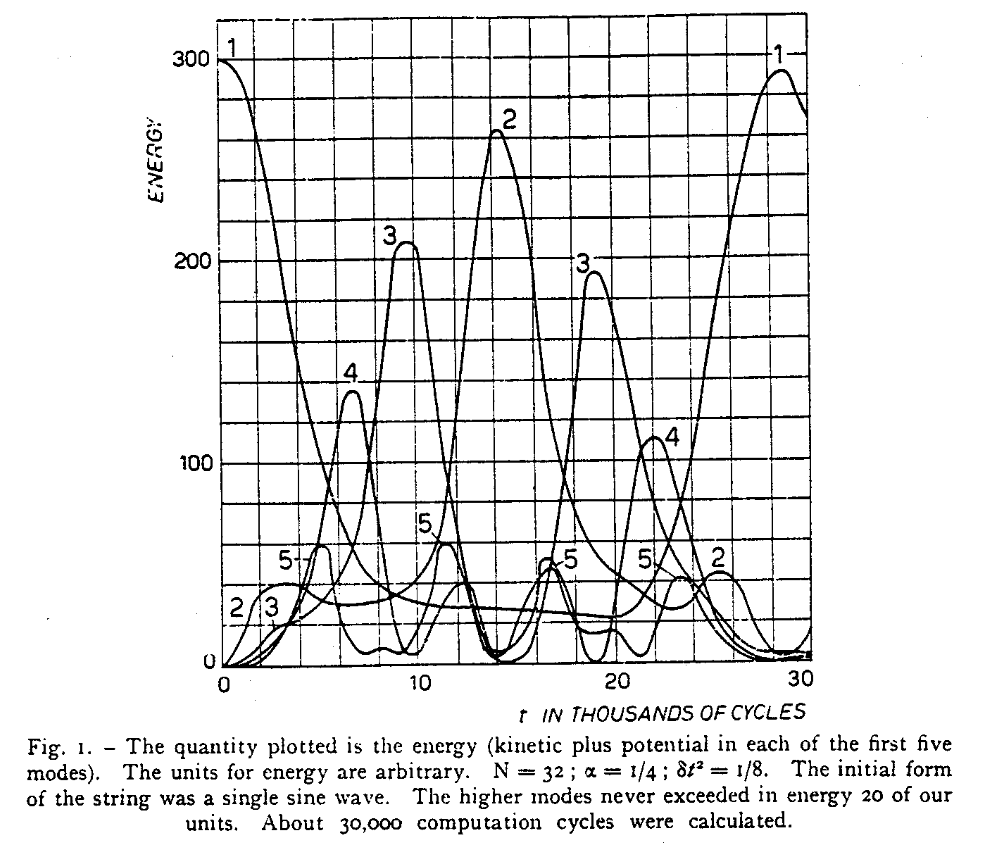
<figcaption aria-hidden="true">Figure 1 from the 1953 FPUT paper.</figcaption>
</figure>

A lot of theoretical progress has been made since then, and the recurrence time can be [analytically estimated](https://arxiv.org/pdf/nlin/0501053) as

$$ T_R = \frac{3}{\pi^{3/2} \sqrt{2}} \frac{N^{3/2}}{\sqrt{A \alpha}} T_1\,,$$

where $N$ is the number of springs, $A$ is the initial amplitude of the fundamental mode’s oscillation, while $T_1 = 2\pi / \omega_1$ is the period of the fundamental oscillation.